Loading 201 snapshots...
Loaded history shape: (201, 113, 128) (Snaps, P, D)
Fitting Cubic Spline to trajectories...
Sampling 100 frames from spline...
Constructed 3D Tensor shape: (100, 113, 128)
Building Cubical Complex (this is fast in C++)...
Computing Persistence...
Found 171731 H1 features
Found 101571 H2 features


c:\Users\tangy\.conda\envs\env_01\lib\site-packages\gudhi\persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


Analysis plot saved to ./runs/modadd_grokking_03\tda_cubical_analysis.png


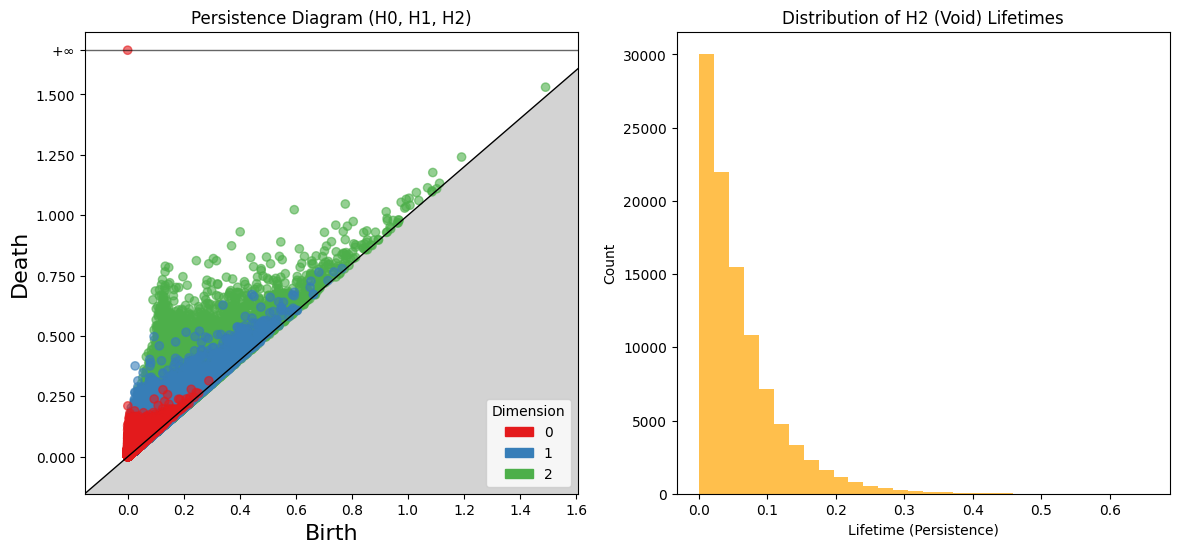

In [ ]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from safetensors.numpy import load_file
import gudhi

RUN_DIR = "./runs/modadd_grokking_03"  
LAYER_NAME = "tok_emb.weight" 
SAMPLE_STEPS = 100           


def load_snapshots(run_dir):
    snap_dir = os.path.join(run_dir, "snapshots")
    files = glob.glob(os.path.join(snap_dir, "*.safetensors"))
    
    if not files:
        raise ValueError(f"No snapshots found in {snap_dir}")
    
    steps = []
    weights = []
    
    print(f"Loading {len(files)} snapshots...")
    for f in files:
        match = re.search(r"step_(\d+)", f)
        if match:
            step = int(match.group(1))
            data = load_file(f)
            if LAYER_NAME in data:
                steps.append(step)
                weights.append(data[LAYER_NAME]) # shape: (p, d_model)
    
    steps = np.array(steps)
    weights = np.array(weights) # shape: (N_snaps, p, d_model)
    
    idx = np.argsort(steps)
    return steps[idx], weights[idx]

def analyze_spacetime_cubical(run_dir):
    # A. 加载数据
    steps, weight_history = load_snapshots(run_dir)
    print(f"Loaded history shape: {weight_history.shape} (Snaps, P, D)")
    
    T_raw, P, D = weight_history.shape
    
    print("Fitting Cubic Spline to trajectories...")

    flat_weights = weight_history.reshape(T_raw, -1)
    spline = CubicSpline(steps, flat_weights, axis=0)
    
    t_eval = np.linspace(steps[0], steps[-1], SAMPLE_STEPS)
    
    print(f"Sampling {SAMPLE_STEPS} frames from spline...")
    tensor_slices = []
    for t in t_eval:
        w_t = spline(t).reshape(P, D)
        tensor_slices.append(np.abs(w_t))
        
    # 堆叠成 3D 张量: (Time, Token, Dim)
    spacetime_tensor = np.array(tensor_slices)
    print(f"Constructed 3D Tensor shape: {spacetime_tensor.shape}")
    
    # D. 构建 Cubical Complex
    print("Building Cubical Complex (this is fast in C++)...")
    cc = gudhi.CubicalComplex(top_dimensional_cells=spacetime_tensor)
    
    # E. 计算同调 (Homology)
    print("Computing Persistence...")
    # homology_coeff_field=2 (Z/2Z) 是标准设置
    cc.compute_persistence(homology_coeff_field=2)
    
    # 获取不同维度的特征
    # H0: 连通分量 (Connected Components)
    # H1: 环 (Loops/Tunnels)
    # H2: 空腔 (Voids) <- 这是我们要找的高维特征
    pers_H1 = cc.persistence_intervals_in_dimension(1)
    pers_H2 = cc.persistence_intervals_in_dimension(2)
    
    print(f"Found {len(pers_H1)} H1 features")
    print(f"Found {len(pers_H2)} H2 features")
    
    return cc, pers_H1, pers_H2

# -----------------------------
# 4. 可视化
# -----------------------------
def plot_results(cc, pers_H1, pers_H2, run_dir):
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Standard Persistence Diagram
    # Gudhi 自带的绘图工具
    gudhi.plot_persistence_diagram(cc.persistence(), axes=axs[0], legend=True)
    axs[0].set_title("Persistence Diagram (H0, H1, H2)")
    
    # Plot 2: H2 Lifetime Histogram (如果有 H2)
    if len(pers_H2) > 0:
        # 寿命 = Death - Birth
        lifetimes = pers_H2[:, 1] - pers_H2[:, 0]
        # 去除 inf (如果有无法死亡的特征)
        lifetimes = lifetimes[np.isfinite(lifetimes)]
        
        axs[1].hist(lifetimes, bins=30, color='orange', alpha=0.7)
        axs[1].set_title("Distribution of H2 (Void) Lifetimes")
        axs[1].set_xlabel("Lifetime (Persistence)")
        axs[1].set_ylabel("Count")
    else:
        axs[1].text(0.5, 0.5, "No H2 features found", ha='center')
        axs[1].set_title("H2 Analysis")

    save_path = os.path.join(run_dir, "tda_cubical_analysis.png")
    plt.savefig(save_path)
    print(f"Analysis plot saved to {save_path}")
    plt.show()

# -----------------------------
# Main
# -----------------------------
if __name__ == "__main__":
    if os.path.exists(RUN_DIR):
        cc, h1, h2 = analyze_spacetime_cubical(RUN_DIR)
        plot_results(cc, h1, h2, RUN_DIR)
    else:
        print(f"Error: Directory {RUN_DIR} not found. Please run training first.")

In [1]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from safetensors.numpy import load_file
import gudhi

RUN_DIR = "./runs/modadd_grokking_03"
LAYER_NAME = "tok_emb.weight"

# ---------- sliding window params ----------
WINDOW_SIZE = 16   # W
STRIDE = 4         # S
MAX_DIM = 2        # compute up to H2 (set 1 if too slow)
OUT_DIRNAME = "tda_cubical_windows"
USE_ABS = True     # keep your original abs
NORMALIZE_PER_WINDOW = False  # optional: z-score per window to reduce scale drift


def load_snapshots(run_dir):
    snap_dir = os.path.join(run_dir, "snapshots")
    files = glob.glob(os.path.join(snap_dir, "*.safetensors"))
    if not files:
        raise ValueError(f"No snapshots found in {snap_dir}")

    steps = []
    weights = []
    for f in files:
        match = re.search(r"step_(\d+)", os.path.basename(f))
        if match:
            step = int(match.group(1))
            data = load_file(f)
            if LAYER_NAME in data:
                steps.append(step)
                weights.append(data[LAYER_NAME])  # (P, D)

    steps = np.array(steps)
    weights = np.array(weights)  # (T, P, D)

    idx = np.argsort(steps)
    return steps[idx], weights[idx]


def _window_tensor(weight_window: np.ndarray) -> np.ndarray:
    """
    weight_window: (W, P, D)
    returns tensor: (W, P, D) float64
    """
    x = weight_window.astype(np.float64, copy=False)
    if USE_ABS:
        x = np.abs(x)

    if NORMALIZE_PER_WINDOW:
        # normalize across the whole window grid
        mu = x.mean()
        sigma = x.std()
        if sigma > 0:
            x = (x - mu) / sigma

    return x


def compute_persistence_for_window(tensor_3d: np.ndarray, max_dim: int = 2):
    """
    tensor_3d: (W, P, D)
    Returns: cc, pers_by_dim dict
    """
    cc = gudhi.CubicalComplex(top_dimensional_cells=tensor_3d)
    cc.compute_persistence(homology_coeff_field=2, min_persistence=0.0)

    pers_by_dim = {}
    for dim in range(0, max_dim + 1):
        pers_by_dim[dim] = cc.persistence_intervals_in_dimension(dim)
    return cc, pers_by_dim


def plot_window_diagram(cc, steps_range, out_path):
    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    gudhi.plot_persistence_diagram(cc.persistence(), axes=ax, legend=True)
    ax.set_title(f"PH Diagram | steps [{steps_range[0]}, {steps_range[1]}]")
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.close(fig)


def sliding_window_cubical_analysis(run_dir, window_size=16, stride=4, max_dim=2):
    steps, weight_history = load_snapshots(run_dir)
    T, P, D = weight_history.shape
    if T < window_size:
        raise ValueError(f"Not enough snapshots: T={T} < window_size={window_size}")

    out_dir = os.path.join(run_dir, OUT_DIRNAME)
    os.makedirs(out_dir, exist_ok=True)

    # store summaries
    records = []

    win_id = 0
    for start in range(0, T - window_size + 1, stride):
        end = start + window_size
        w_win = weight_history[start:end]  # (W, P, D)
        s0, s1 = int(steps[start]), int(steps[end - 1])

        tensor_3d = _window_tensor(w_win)

        cc, pers_by_dim = compute_persistence_for_window(tensor_3d, max_dim=max_dim)

        # summary metrics (example)
        def max_persistence(intervals):
            if intervals is None or len(intervals) == 0:
                return 0.0
            intervals = np.asarray(intervals)
            lifetimes = intervals[:, 1] - intervals[:, 0]
            lifetimes = lifetimes[np.isfinite(lifetimes)]
            return float(lifetimes.max()) if lifetimes.size > 0 else 0.0

        h1_max = max_persistence(pers_by_dim.get(1, []))
        h2_max = max_persistence(pers_by_dim.get(2, [])) if max_dim >= 2 else 0.0

        # save diagram
        diag_path = os.path.join(out_dir, f"win_{win_id:04d}_steps_{s0}_{s1}.png")
        plot_window_diagram(cc, (s0, s1), diag_path)

        records.append({
            "win_id": win_id,
            "start_idx": start,
            "end_idx": end - 1,
            "step_start": s0,
            "step_end": s1,
            "H1_max_persistence": h1_max,
            "H2_max_persistence": h2_max,
            "num_H1": int(len(pers_by_dim.get(1, []))),
            "num_H2": int(len(pers_by_dim.get(2, []))) if max_dim >= 2 else 0
        })

        print(f"[win {win_id:04d}] steps [{s0},{s1}] | "
              f"H1_max={h1_max:.4g}, H2_max={h2_max:.4g} | "
              f"saved {os.path.basename(diag_path)}")

        win_id += 1

    # save csv-like summary
    summary_path = os.path.join(out_dir, "summary.tsv")
    with open(summary_path, "w", encoding="utf-8") as f:
        header = list(records[0].keys())
        f.write("\t".join(header) + "\n")
        for r in records:
            f.write("\t".join(str(r[h]) for h in header) + "\n")

    print(f"All done. Diagrams + summary saved to: {out_dir}")
    print(f"Summary file: {summary_path}")
    return records


if __name__ == "__main__":
    if os.path.exists(RUN_DIR):
        sliding_window_cubical_analysis(
            RUN_DIR,
            window_size=WINDOW_SIZE,
            stride=STRIDE,
            max_dim=MAX_DIM
        )
    else:
        print(f"Error: Directory {RUN_DIR} not found.")


c:\Users\tangy\.conda\envs\env_01\lib\site-packages\gudhi\persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


[win 0000] steps [1,7500] | H1_max=0.5556, H2_max=0.4182 | saved win_0000_steps_1_7500.png
[win 0001] steps [2000,9500] | H1_max=0.4644, H2_max=0.5184 | saved win_0001_steps_2000_9500.png
[win 0002] steps [4000,11500] | H1_max=0.3031, H2_max=0.5629 | saved win_0002_steps_4000_11500.png
[win 0003] steps [6000,13500] | H1_max=0.2085, H2_max=0.465 | saved win_0003_steps_6000_13500.png
[win 0004] steps [8000,15500] | H1_max=0.1938, H2_max=0.5399 | saved win_0004_steps_8000_15500.png
[win 0005] steps [10000,17500] | H1_max=0.1855, H2_max=0.5049 | saved win_0005_steps_10000_17500.png
[win 0006] steps [12000,19500] | H1_max=0.211, H2_max=0.5517 | saved win_0006_steps_12000_19500.png
[win 0007] steps [14000,21500] | H1_max=0.2025, H2_max=0.5495 | saved win_0007_steps_14000_21500.png
[win 0008] steps [16000,23500] | H1_max=0.2529, H2_max=0.4039 | saved win_0008_steps_16000_23500.png
[win 0009] steps [18000,25500] | H1_max=0.1961, H2_max=0.4515 | saved win_0009_steps_18000_25500.png
[win 0010] s